## 检查6张表格的内容和缺漏

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. DA_codebook_full.xlsx

个人信息标签（包含心理测试表）：301个

生理指标检测标签：95个

### 2. DA_daily_diet.xlsx

这份数据主要记录了200名戒毒人员每日摄入的营养成分和热量总和。

- 数据缺失：DA163

- 并非所有戒毒人员都拥有完整的15天餐食记录。其中：

    8名人员仅记录了1-2天
    
    57名人员记录了8天

    134名人员拥有完整的15天数据



In [42]:
dd_path = r"C:\Users\adayc\Desktop\code\Drug\DA_data\DA_daily_diet.xlsx"
dd = pd.read_excel(dd_path)

# get column names
column_names = dd.columns.tolist()
print(f"Got {len(column_names)-3} features. They are: {column_names[3:]}.")

# check ID column
existing_ids = set(dd[dd.columns[1]].unique())
expected_ids = set(range(1, 201)) 
missing_ids = sorted(expected_ids - existing_ids)
print(f"Missing {len(missing_ids)} DA_ID：{missing_ids}.")

Got 22 features. They are: ['s_能量千卡', 's_蛋白质克', 's_脂肪克', 's_碳水化物克', 's_膳食纤维克', 's_胆固醇毫克', 's_维生素A视黄醇当量μg', 's_维生素B1毫克', 's_维生素B2毫克', 's_烟酸毫克', 's_维生素C毫克', 's_维生素E毫克', 's_钙毫克', 's_磷毫克', 's_钾毫克', 's_钠毫克', 's_镁毫克', 's_铁毫克', 's_锌毫克', 's_硒ug', 's_铜毫克', 's_锰毫克'].
Missing 1 DA_ID：[163].


In [43]:
# Record days count
participant_days = dd.groupby(dd.columns[0])[dd.columns[2]].nunique()
days_count = participant_days.value_counts().sort_index()

# Record days not 8 or 15 days
less_than_5_days = participant_days[(participant_days != 8) & (participant_days != 15)].reset_index()
less_than_5_days.columns = ["ID", "Record days"]
stats_df = pd.DataFrame({'Record days': days_count.index, 'Num. participants': days_count.values})

print("Table of record days：")
print(stats_df.to_string(index=False))
print("\nRecord IDs with days not 8 or 15 days：")
print(less_than_5_days.to_string(index=False))

Table of record days：
 Record days  Num. participants
           3                  1
           5                  1
           7                  2
           8                 57
          10                  1
          11                  1
          13                  1
          14                  1
          15                134

Record IDs with days not 8 or 15 days：
   ID  Record days
DA091            5
DA104            7
DA106            7
DA148           10
DA171           11
DA183           13
DA184           14
DA196            3


### 3. DA_daily_food_clean.xlsx

这份表格主要记录了200名戒毒人员每日的饮食情况，包括食物名称、进食时间、食用量，以及食物的能量和营养价值。基本每人每日有进食3-4餐的记录，其中DA 98和99在11.10（星期天）只有2次进食记录，分别为中餐和晚餐。

- 无数据缺失

- 并非所有戒毒人员都拥有完整的餐食记录。其中：
    
    60名人员记录了8天：比表1多出DA 91、104、106

    140名人员记录了15天：比表1多出DA 148、163、171、183、184、196

    其余数据记录天数与表1相同

In [16]:
dfc = pd.read_excel(r'C:\Users\adayc\Desktop\code\Drug\DA_data\DA_daily_food_clean.xlsx')
#print(dfc.info())

# Check missing ID
full_list = {f"DA{i:03d}" for i in range(1, 201)}
existing_list = set(dfc['Sampleid'])
missing_values = full_list - existing_list
print("Missing ID: ", sorted(missing_values))

Missing ID:  []


Meal count distribution per day:
TIME
4    1542
3    1036
2       2
Name: count, dtype: int64


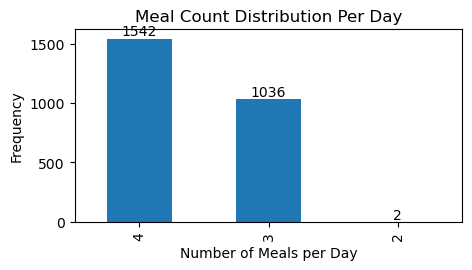

Days with exactly 2 meals:
Sampleid  DAY       
DA098     11.10(星期天)    2
DA099     11.10(星期天)    2
Name: TIME, dtype: int64


In [62]:
# Check meal time
complete_meal = dfc.groupby(['Sampleid', 'DAY'])['TIME'].nunique()
meal_count_distribution = complete_meal.value_counts()

print("Meal count distribution per day:")
print(meal_count_distribution)

# Plot meal count distribution
ax = meal_count_distribution.plot(kind='bar', figsize=(5, 2.5))
plt.title("Meal Count Distribution Per Day")
plt.xlabel("Number of Meals per Day")
plt.ylabel("Frequency")
for i, v in enumerate(meal_count_distribution):
    ax.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=10)
plt.show()

# Days with exactly 2 meals
two_meal_days = complete_meal[complete_meal == 2]
print("Days with exactly 2 meals:")
print(two_meal_days)

In [38]:
# Record days count
participant_days_dfc = dfc.groupby('Sampleid')['DAY'].nunique()
days_count_dfc = participant_days_dfc.value_counts().sort_index()
stats_df_dfc = pd.DataFrame({'Record days': days_count_dfc.index, 'Num. participants': days_count_dfc.values})

print("Table of record days：")
print(stats_df_dfc.to_string(index=False))

Table of record days：
 Record days  Num. participants
           8                 60
          15                140


In [53]:
# Compare table 1 and 2
day_t1 = participant_days.reset_index()
day_t2 = participant_days_dfc.reset_index()

difference = pd.merge(day_t1[['Sampleid', 'DAY']], day_t2[['Sampleid', 'DAY']], 
                       on=['Sampleid', 'DAY'], how='outer', indicator=True)
different_rows = difference[difference['_merge'] != 'both']

print("Rows with different data:")
print(different_rows)

Rows with different data:
    Sampleid  DAY      _merge
90     DA091    5   left_only
91     DA091    8  right_only
104    DA104    7   left_only
105    DA104    8  right_only
107    DA106    7   left_only
108    DA106    8  right_only
150    DA148   10   left_only
151    DA148   15  right_only
166    DA163   15  right_only
174    DA171   11   left_only
175    DA171   15  right_only
187    DA183   13   left_only
188    DA183   15  right_only
189    DA184   14   left_only
190    DA184   15  right_only
202    DA196    3   left_only
203    DA196   15  right_only


### 4. DA_daily_meal.xlsx

这份表格主要记录了200名戒毒人员每日的饮食情况，是表3的总和版，不包括单独食物名称、食用量，仅有进食时间和能量、营养价值每餐总和。

- 无数据缺失

- 餐食数据记录与表3完全一样，ID与进食数量对应一致

In [ ]:
dm = pd.read_excel(r'C:\Users\adayc\Desktop\code\Drug\DA_data\DA_daily_meal.xlsx')
#print(dm.info())

# Check missing ID
full_list = {f"DA{i:03d}" for i in range(1, 201)}
existing_list = set(dm['Sampleid'])
missing_values = full_list - existing_list
print("Missing ID: ", sorted(missing_values))

Missing ID: 0


In [ ]:
# Check if it is the same as the previous table
# Record days count
participant_days_dm = dm.groupby('Sampleid')['DAY'].nunique()
days_count_dm = participant_days_dm.value_counts().sort_index()
stats_df_dm = pd.DataFrame({'Record days': days_count_dm.index, 'Num. participants': days_count_dm.values})

print("Table of record days：")
print(stats_df_dm.to_string(index=False))

Table of record days：
 Record days  Num. participants
           8                 60
          15                140


Meal count distribution per day:
TIME
4    1542
3    1036
2       2
Name: count, dtype: int64


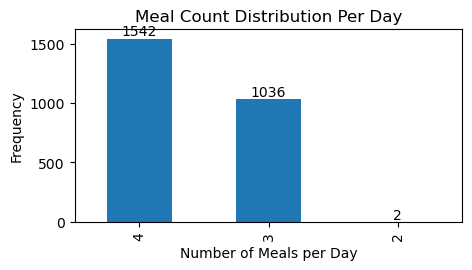

Days with exactly 2 meals:
Sampleid  DAY       
DA098     11.10(星期天)    2
DA099     11.10(星期天)    2
Name: TIME, dtype: int64


In [6]:
# Check meal time
complete_meal = dm.groupby(['Sampleid', 'DAY'])['TIME'].nunique()
meal_count_distribution = complete_meal.value_counts()

print("Meal count distribution per day:")
print(meal_count_distribution)

# Plot meal count distribution
ax = meal_count_distribution.plot(kind='bar', figsize=(5, 2.5))
plt.title("Meal Count Distribution Per Day")
plt.xlabel("Number of Meals per Day")
plt.ylabel("Frequency")
for i, v in enumerate(meal_count_distribution):
    ax.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=10)
plt.show()

# Days with exactly 2 meals
two_meal_days = complete_meal[complete_meal == 2]
print("Days with exactly 2 meals:")
print(two_meal_days)

### 5. DA_mean_diet.xlsx

这份表格主要记录了200名戒毒人员每日饮食情况的能量、营养价值平均值。

表3（摄入食物细节） -> 表4（每餐摄入总和） -> 表2（每日摄入总和）-> 表5（每日摄入平均值）

- 数据缺失：DA163

- 部分天数缺失原因：摄入食物数量为0，故无法统计

In [13]:
md = pd.read_excel(r'C:\Users\adayc\Desktop\code\Drug\DA_data\DA_mean_diet.xlsx')

# Check missing ID
full_list = {f"DA{i:03d}" for i in range(1, 201)}
existing_list = set(md['SampleID'])
missing_values = full_list - existing_list
print("Missing ID: ", sorted(missing_values))

Missing ID:  ['DA163']


### 6. DA_phenotype.xlsx

这份表格主要记录了所有参与人员的个人信息，以及戒毒人员和正常人的心理评估和生理检查数据。需要对照表1代码完成编号对照。


- 无数据缺失：200名戒毒人员（编号连贯DA001-DA200），112名正常人（编号不连贯）

- 健康人群缺少部分个人信息，无心理评估表评分，部分无BMI信息，无部分生理检测数据

**查看codes\preprocess\clean_phenotype.py以获取该表的清理和修改过程**

In [17]:
phenotype = pd.read_excel(r'C:\Users\adayc\Desktop\code\Drug\DA_data\DA_phenotype.xlsx')
phenotype

,ID,type,center,brigade,IDNUM,start_date,birthplace,intime,AGE,SEX,...,TRF,PLT,MPV,PCT,HbA1c,MetSI,CVAI,LAP,VAI,Prealbumin
0,DA001,1,1,A-3,430526199201110022,10/28/2019,湖南,6.0,27,2,...,3.30,278.0,9.8,0.27,5.10,1.0,28.140216,19.600,1.792133,148.0
1,DA002,1,1,A-3,330225198210231589,10/28/2019,浙江,6.0,37,2,...,1.89,155.0,9.8,0.15,5.26,0.0,38.992137,20.240,1.225442,228.0
2,DA003,1,1,A-3,421281198904230023,10/28/2019,湖北,6.0,30,2,...,2.95,262.0,9.4,0.25,5.57,0.0,-1.262350,10.665,1.014654,227.0
3,DA004,1,1,A-3,330225198312242561,10/28/2019,浙江,6.0,35,2,...,2.53,186.0,11.6,0.22,5.65,2.0,52.747485,23.240,1.628229,102.0
4,DA005,1,1,A-3,33024197501101128,10/28/2019,浙江,6.0,44,2,...,3.16,410.0,9.8,0.40,5.14,0.0,42.615782,9.200,0.783288,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,G2PN026,2,4,NaN,NaN,NaN,河南-郑州,NaN,27,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
308,G2PN027,2,4,NaN,NaN,NaN,宁夏-固原,NaN,23,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
309,G2PN028,2,4,NaN,NaN,NaN,山东-聊城,NaN,31,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
310,G2PN029,2,4,NaN,NaN,NaN,河北-沧州,NaN,26,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
